# **Installing (Vision Transformer Model)**

In [1]:
!pip install -q timm

# **Imports, Device, and Seeds**

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms

import timm
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# --- Reproducibility ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cuda


# **Mounting Drive & Unziping Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/ChestXRay2017.zip"

# Unzip into /content
!unzip -q "{ZIP_PATH}" -d "/content"

# After unzip, adjust this if your folder name is slightly different
DATA_ROOT = "/content/chest_xray"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TEST_DIR  = os.path.join(DATA_ROOT, "test")

print("Train dir:", TRAIN_DIR)
print("Test dir :", TEST_DIR)
print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes :", os.listdir(TEST_DIR))

Mounted at /content/drive
Train dir: /content/chest_xray/train
Test dir : /content/chest_xray/test
Train classes: ['NORMAL', 'PNEUMONIA', '.DS_Store']
Test classes : ['NORMAL', 'PNEUMONIA', '.DS_Store']


In [4]:
import os

def remove_ds_store(root_dir):
    removed = 0
    for root, dirs, files in os.walk(root_dir):
        for f in files:
            if f == ".DS_Store":
                path = os.path.join(root, f)
                os.remove(path)
                removed += 1
    print(f"Removed {removed} .DS_Store files from {root_dir}")

remove_ds_store(TRAIN_DIR)
remove_ds_store(TEST_DIR)

print("After cleanup:")
print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes :", os.listdir(TEST_DIR))

Removed 2 .DS_Store files from /content/chest_xray/train
Removed 1 .DS_Store files from /content/chest_xray/test
After cleanup:
Train classes: ['NORMAL', 'PNEUMONIA']
Test classes : ['NORMAL', 'PNEUMONIA']


# **Transforms and Datasets (Classification + AutoEncoder)**

In [5]:
# ImageNet normalization (because ViT is ImageNet-pretrained)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# For ViT classifier (RGB 224x224 + normalization)
vit_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

vit_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# For Autoencoder (we keep intensities in [0,1], no normalization)
ae_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),  # AE works on single channel CXR
    transforms.ToTensor(),
])

# --- Classification datasets ---
full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=vit_train_transform)
test_dataset_cls   = datasets.ImageFolder(TEST_DIR,  transform=vit_test_transform)

print("Classes (index -> name):", full_train_dataset.class_to_idx)

# Split train into train + val (e.g. 85% / 15%)
val_ratio = 0.15
n_total = len(full_train_dataset)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

train_dataset_cls, val_dataset_cls = random_split(
    full_train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train samples: {len(train_dataset_cls)}, Val samples: {len(val_dataset_cls)}, Test samples: {len(test_dataset_cls)}")

# --- Autoencoder datasets ---
# We create separate AE datasets that use grayscale transform.
full_train_dataset_ae = datasets.ImageFolder(TRAIN_DIR, transform=ae_transform)
test_dataset_ae       = datasets.ImageFolder(TEST_DIR,  transform=ae_transform)

print("AE train size:", len(full_train_dataset_ae))
print("AE test size :", len(test_dataset_ae))

Classes (index -> name): {'NORMAL': 0, 'PNEUMONIA': 1}
Train samples: 4448, Val samples: 784, Test samples: 624
AE train size: 5232
AE test size : 624


# **DataLoaders + Simple Class Distribution Plot**

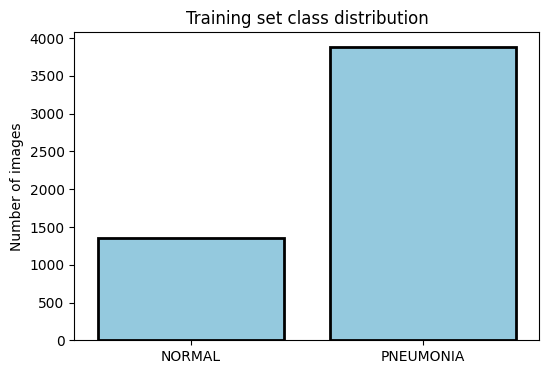

{'NORMAL': 1349, 'PNEUMONIA': 3883}


In [6]:
BATCH_SIZE = 16

train_loader_cls = DataLoader(train_dataset_cls, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader_cls   = DataLoader(val_dataset_cls,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_cls  = DataLoader(test_dataset_cls,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# For AE we will later build a special "NORMAL-only" dataset, so no loader here yet.

# --- Visualize class distribution in train set ---
class_names = full_train_dataset.classes  # ['NORMAL', 'PNEUMONIA']
class_to_idx = full_train_dataset.class_to_idx

counts = [0, 0]
for _, label in full_train_dataset:
    counts[label] += 1

plt.figure(figsize=(6,4))
sns.barplot(x=class_names, y=counts, color="skyblue", edgecolor='black', linewidth=2)
plt.title("Training set class distribution")
plt.ylabel("Number of images")
plt.savefig('Training_set_class_distribution.png', dpi=300)
plt.show()

print(dict(zip(class_names, counts)))

# **ViT Classifier Model (DeiT-Base)**

In [7]:
class ViTPneumoniaClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # deit_base_patch16_224 with pretrained ImageNet weights
        self.model = timm.create_model(
            "deit_base_patch16_224",
            pretrained=True,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.model(x)

vit_model = ViTPneumoniaClassifier(num_classes=2).to(DEVICE)

# Freeze some early layers if you want faster / more stable training (optional)
# for name, param in vit_model.named_parameters():
#     if "head" not in name:
#         param.requires_grad = False

print(vit_model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViTPneumoniaClassifier(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
  

# **Training & Validation Utilities (Cassifier)**

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

# **Training ViT Classifier + Learning Curves**

In [9]:
EPOCHS_CLS = 15
LR_CLS = 1e-5

criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = torch.optim.Adam(vit_model.parameters(), lr=LR_CLS)

# Optional scheduler with multiplicative factor ~0.995 per epoch (like paper)
scheduler_cls = torch.optim.lr_scheduler.MultiplicativeLR(
    optimizer_cls, lr_lambda=lambda epoch: 0.995
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

for epoch in range(1, EPOCHS_CLS + 1):
    train_loss, train_acc = train_one_epoch(
        vit_model, train_loader_cls, criterion_cls, optimizer_cls, DEVICE
    )
    val_loss, val_acc = evaluate(
        vit_model, val_loader_cls, criterion_cls, DEVICE
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    scheduler_cls.step()

    print(f"[Epoch {epoch:02d}/{EPOCHS_CLS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% || "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

[Epoch 01/15] Train Loss: 0.1135 | Train Acc: 95.73% || Val Loss: 0.0622 | Val Acc: 98.09%
[Epoch 02/15] Train Loss: 0.0490 | Train Acc: 98.34% || Val Loss: 0.0673 | Val Acc: 97.32%
[Epoch 03/15] Train Loss: 0.0353 | Train Acc: 98.90% || Val Loss: 0.0448 | Val Acc: 98.60%
[Epoch 04/15] Train Loss: 0.0363 | Train Acc: 98.72% || Val Loss: 0.0572 | Val Acc: 97.96%
[Epoch 05/15] Train Loss: 0.0248 | Train Acc: 99.21% || Val Loss: 0.0367 | Val Acc: 98.47%
[Epoch 06/15] Train Loss: 0.0233 | Train Acc: 99.17% || Val Loss: 0.0560 | Val Acc: 98.47%
[Epoch 07/15] Train Loss: 0.0202 | Train Acc: 99.35% || Val Loss: 0.0428 | Val Acc: 98.98%
[Epoch 08/15] Train Loss: 0.0162 | Train Acc: 99.48% || Val Loss: 0.0486 | Val Acc: 97.96%
[Epoch 09/15] Train Loss: 0.0086 | Train Acc: 99.71% || Val Loss: 0.0485 | Val Acc: 97.96%
[Epoch 10/15] Train Loss: 0.0120 | Train Acc: 99.53% || Val Loss: 0.0501 | Val Acc: 98.72%
[Epoch 11/15] Train Loss: 0.0194 | Train Acc: 99.33% || Val Loss: 0.0420 | Val Acc: 98.60%

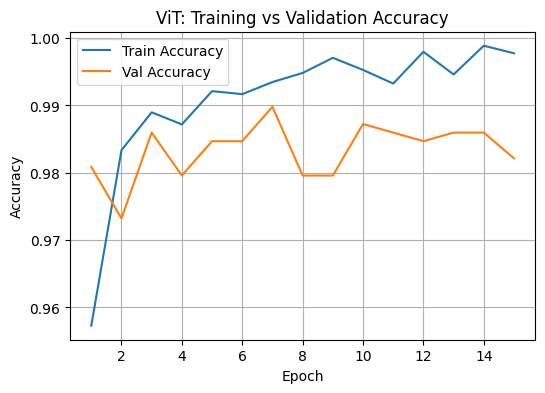

In [10]:
# --- Plot accuracy ---
epochs_range = range(1, EPOCHS_CLS + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig('Vit_training_validation_accuracy.png', dpi=300)
plt.show()

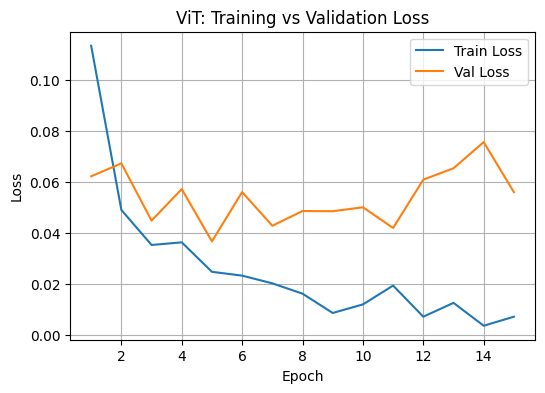

In [11]:
# --- Plot loss ---
plt.figure(figsize=(6,4))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig('Vit_training_validation_loss.png', dpi=300)
plt.show()

# **Test evaluation + Confusion Matrix**

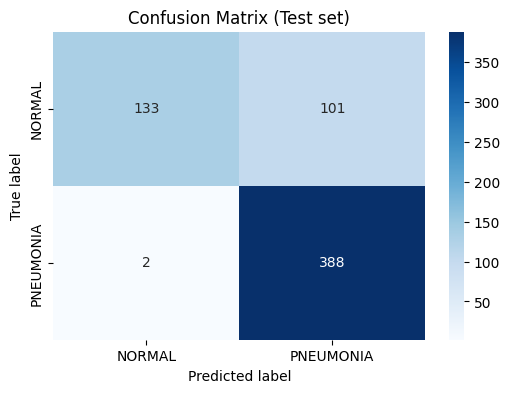

Raw confusion matrix:
 [[133 101]
 [  2 388]]


In [12]:
vit_model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader_cls:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = vit_model(images)
        probs = F.softmax(outputs, dim=1)[:, 1]  # probability of class "PNEUMONIA"

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_dataset_cls.classes,
            yticklabels=test_dataset_cls.classes)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Test set)")
plt.savefig('Vit_confusion_matrix(test set).png', dpi=300)
plt.show()

print("Raw confusion matrix:\n", cm)

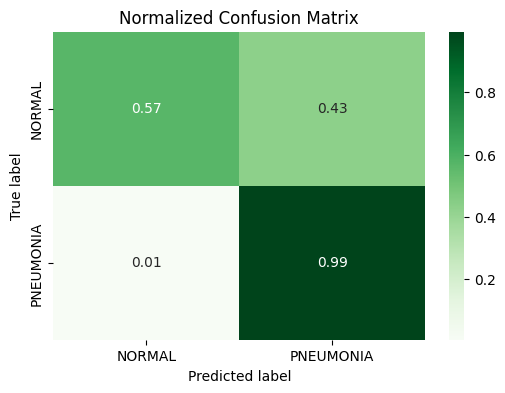

In [13]:
# --- Normalized confusion matrix ---
plt.figure(figsize=(6,4))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=test_dataset_cls.classes,
            yticklabels=test_dataset_cls.classes)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix")
plt.savefig('Vit_normalized_confusion_matrix.png', dpi=300)
plt.show()

# **Classification Report**

In [14]:
# --- Classification report ---
print("\nClassification report:")
print(classification_report(
    y_true, y_pred,
    target_names=test_dataset_cls.classes,
    digits=4
))


Classification report:
              precision    recall  f1-score   support

      NORMAL     0.9852    0.5684    0.7209       234
   PNEUMONIA     0.7935    0.9949    0.8828       390

    accuracy                         0.8349       624
   macro avg     0.8893    0.7816    0.8018       624
weighted avg     0.8654    0.8349    0.8221       624



# **ROC Curve**

ROC-AUC: 0.9665


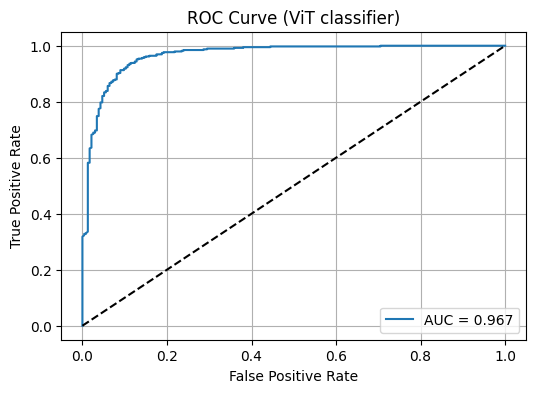

In [15]:
# --- ROC-AUC ---
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)
print(f"ROC-AUC: {auc_score:.4f}")

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ViT classifier)")
plt.legend()
plt.grid(True)
plt.savefig('Vit_ROC_curve.png', dpi=300)
plt.show()

# **NORMAL-only Dataset for Generative Autoencoder**

In [16]:
# We use the AE transform (grayscale) and keep only NORMAL class (index 0)
ae_full = full_train_dataset_ae  # ImageFolder(train_dir, ae_transform)
print("AE classes:", ae_full.classes, ae_full.class_to_idx)

normal_class_idx = ae_full.class_to_idx["NORMAL"]

normal_indices = [i for i, (_, label) in enumerate(ae_full.samples)
                  if label == normal_class_idx]

print("Total NORMAL images for AE:", len(normal_indices))

class NormalChestDataset(Dataset):
    def __init__(self, base_dataset, indices):
        self.base = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, _ = self.base[real_idx]  # ignore label
        return img

normal_dataset = NormalChestDataset(ae_full, normal_indices)

# Train/val split for AE (e.g., 90% / 10%)
n_total = len(normal_dataset)
n_val = int(0.1 * n_total)
n_train = n_total - n_val

ae_train_dataset, ae_val_dataset = random_split(
    normal_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

ae_train_loader = DataLoader(ae_train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
ae_val_loader   = DataLoader(ae_val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"AE train size: {len(ae_train_dataset)}, AE val size: {len(ae_val_dataset)}")

AE classes: ['NORMAL', 'PNEUMONIA'] {'NORMAL': 0, 'PNEUMONIA': 1}
Total NORMAL images for AE: 1349
AE train size: 1215, AE val size: 134


# **Convolutional Autoencoder (Generative Branch)**

In [17]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: compress 1x224x224 -> 256x14x14
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # 112x112
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 56x56
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 28x28
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),# 14x14
            nn.ReLU(inplace=True),
        )
        # Decoder: 256x14x14 -> 1x224x224
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2,
                               padding=1, output_padding=1),        # 28x28
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2,
                               padding=1, output_padding=1),        # 56x56
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2,
                               padding=1, output_padding=1),        # 112x112
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2,
                               padding=1, output_padding=1),        # 224x224
            nn.Sigmoid(),  # output in [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

ae_model = ConvAutoencoder().to(DEVICE)
print(ae_model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
 

# **Train Generative AutoEncoder**

In [18]:
EPOCHS_AE = 20
LR_AE = 1e-3

criterion_ae = nn.MSELoss()
optimizer_ae = torch.optim.Adam(ae_model.parameters(), lr=LR_AE)

ae_history = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS_AE + 1):
    # ---- train ----
    ae_model.train()
    running_train_loss = 0.0
    n_train = 0

    for imgs in ae_train_loader:
        imgs = imgs.to(DEVICE)

        optimizer_ae.zero_grad()
        recon = ae_model(imgs)
        loss = criterion_ae(recon, imgs)
        loss.backward()
        optimizer_ae.step()

        running_train_loss += loss.item() * imgs.size(0)
        n_train += imgs.size(0)

    train_loss = running_train_loss / n_train

    # ---- val ----
    ae_model.eval()
    running_val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for imgs in ae_val_loader:
            imgs = imgs.to(DEVICE)
            recon = ae_model(imgs)
            loss = criterion_ae(recon, imgs)
            running_val_loss += loss.item() * imgs.size(0)
            n_val += imgs.size(0)

    val_loss = running_val_loss / n_val

    ae_history["train_loss"].append(train_loss)
    ae_history["val_loss"].append(val_loss)

    print(f"[AE Epoch {epoch:02d}/{EPOCHS_AE}] "
          f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

[AE Epoch 01/20] Train Loss: 0.032451 | Val Loss: 0.008223
[AE Epoch 02/20] Train Loss: 0.006088 | Val Loss: 0.004739
[AE Epoch 03/20] Train Loss: 0.004526 | Val Loss: 0.003941
[AE Epoch 04/20] Train Loss: 0.003605 | Val Loss: 0.003831
[AE Epoch 05/20] Train Loss: 0.003597 | Val Loss: 0.003109
[AE Epoch 06/20] Train Loss: 0.002978 | Val Loss: 0.002853
[AE Epoch 07/20] Train Loss: 0.002653 | Val Loss: 0.002579
[AE Epoch 08/20] Train Loss: 0.002722 | Val Loss: 0.002473
[AE Epoch 09/20] Train Loss: 0.002351 | Val Loss: 0.002445
[AE Epoch 10/20] Train Loss: 0.002225 | Val Loss: 0.003898
[AE Epoch 11/20] Train Loss: 0.002214 | Val Loss: 0.001931
[AE Epoch 12/20] Train Loss: 0.001788 | Val Loss: 0.001708
[AE Epoch 13/20] Train Loss: 0.001831 | Val Loss: 0.001606
[AE Epoch 14/20] Train Loss: 0.001514 | Val Loss: 0.001481
[AE Epoch 15/20] Train Loss: 0.001566 | Val Loss: 0.001432
[AE Epoch 16/20] Train Loss: 0.001358 | Val Loss: 0.001346
[AE Epoch 17/20] Train Loss: 0.001421 | Val Loss: 0.0012

# **Reconstruction-Loss Curves**

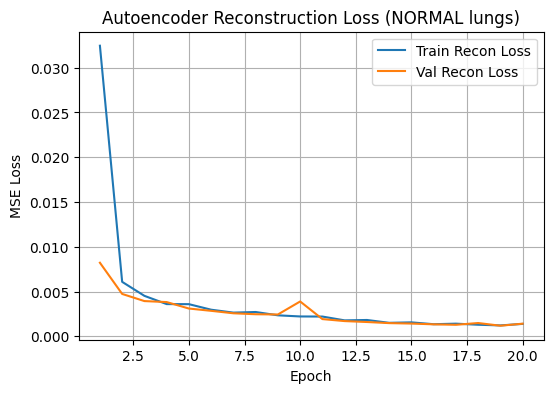

In [19]:
# --- Plot AE reconstruction loss ---
epochs_range_ae = range(1, EPOCHS_AE + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_range_ae, ae_history["train_loss"], label="Train Recon Loss")
plt.plot(epochs_range_ae, ae_history["val_loss"], label="Val Recon Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Reconstruction Loss (NORMAL lungs)")
plt.legend()
plt.grid(True)
plt.savefig('AE_reconstruction_loss.png', dpi=300)
plt.show()

# **Helper Computing Generative Attention Maps**

In [20]:
def generate_attention_map(ae_model, img_tensor, device):
    """
    img_tensor: 1x224x224 (already in [0,1], grayscale) CPU tensor
    Returns: orig, recon, heatmap (all numpy arrays)
    """
    ae_model.eval()
    with torch.no_grad():
        inp = img_tensor.unsqueeze(0).to(device)  # (1,1,224,224)
        recon = ae_model(inp).cpu().squeeze(0).squeeze(0)  # 224x224

    orig = img_tensor.squeeze(0)  # 224x224

    error = torch.abs(orig - recon)
    # Normalize error map to [0,1]
    min_val = error.min()
    max_val = error.max()
    heatmap = (error - min_val) / (max_val - min_val + 1e-8)

    return orig.numpy(), recon.numpy(), heatmap.numpy()

# **Picking TP / FP / FN examples and Visualize Explanations**

In [21]:
# Select TP / FP / FN indices and visualize generative attention
# 1) Reuse datasets (same order as during evaluation)
test_dataset_cls_for_indices = test_dataset_cls        # ImageFolder with RGB + norm
test_dataset_ae_for_maps    = test_dataset_ae         # ImageFolder with grayscale

# 2) TP, FP, FN indices (already computed from y_true / y_pred)
tp_indices = np.where((y_true == 1) & (y_pred == 1))[0]
fp_indices = np.where((y_true == 0) & (y_pred == 1))[0]
fn_indices = np.where((y_true == 1) & (y_pred == 0))[0]

print(f"TP examples: {len(tp_indices)}, FP: {len(fp_indices)}, FN: {len(fn_indices)}")

def show_explainable_example(global_index, cls_dataset, ae_dataset,
                             cls_model, ae_model, device):
    """
    Visualize one case: original, reconstructed, and generative attention map.
    Works whether cls_dataset is ImageFolder or Subset(ImageFolder).
    """
    # --- Classification view (for predicted label & probability) ---
    img_cls, label_cls = cls_dataset[global_index]   # normalized RGB tensor
    img_cls_batch = img_cls.unsqueeze(0).to(device)

    cls_model.eval()
    with torch.no_grad():
        logits = cls_model(img_cls_batch)
        probs = F.softmax(logits, dim=1)[0]
        pred_label = torch.argmax(probs).item()
        prob_pneu = probs[1].item()

    # --- Generative AE view (grayscale) ---
    img_ae, label_ae = ae_dataset[global_index]      # 1x224x224 in [0,1]
    orig, recon, heatmap = generate_attention_map(ae_model, img_ae, device)

    # Handle both ImageFolder and Subset(ImageFolder)
    if hasattr(cls_dataset, "dataset"):
        underlying_dataset = cls_dataset.dataset
    else:
        underlying_dataset = cls_dataset

    class_names = underlying_dataset.classes  # ['NORMAL', 'PNEUMONIA']
    true_name = class_names[label_cls]
    pred_name = class_names[pred_label]

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(12,4))

    axes[0].imshow(orig, cmap="gray")
    axes[0].set_title(f"Original CXR\nTrue: {true_name}")
    axes[0].axis("off")

    axes[1].imshow(recon, cmap="gray")
    axes[1].set_title("Autoencoder Reconstruction\n(learned normal lung prior)")
    axes[1].axis("off")

    axes[2].imshow(orig, cmap="gray")
    im = axes[2].imshow(heatmap, cmap="jet", alpha=0.5)
    axes[2].set_title(
        f"Generated Attention Map\nPred: {pred_name}, P(pneumonia)={prob_pneu:.2f}"
    )
    axes[2].axis("off")

    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="Reconstruction error")
    plt.tight_layout()
    plt.show()


# --- Show a few examples ---
max_examples = 3

print("\nTrue Positive examples: correctly detected pneumonia")
for i in tp_indices[:max_examples]:
    show_explainable_example(int(i),
                             test_dataset_cls_for_indices,
                             test_dataset_ae_for_maps,
                             vit_model, ae_model, DEVICE)

if len(fp_indices) > 0:
    print("\nFalse Positive examples: normal misclassified as pneumonia")
    for i in fp_indices[:max_examples]:
        show_explainable_example(int(i),
                                 test_dataset_cls_for_indices,
                                 test_dataset_ae_for_maps,
                                 vit_model, ae_model, DEVICE)

if len(fn_indices) > 0:
    print("\nFalse Negative examples: pneumonia missed by classifier")
    for i in fn_indices[:max_examples]:
        show_explainable_example(int(i),
                                 test_dataset_cls_for_indices,
                                 test_dataset_ae_for_maps,
                                 vit_model, ae_model, DEVICE)

Output hidden; open in https://colab.research.google.com to view.

# **Quantitative View of Generative Branch (Error Distributions)**

/tmp/ipython-input-2779682679.py:23: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(errors_normal, label="NORMAL", shade=True)
/tmp/ipython-input-2779682679.py:24: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(errors_pneu,   label="PNEUMONIA", shade=True)


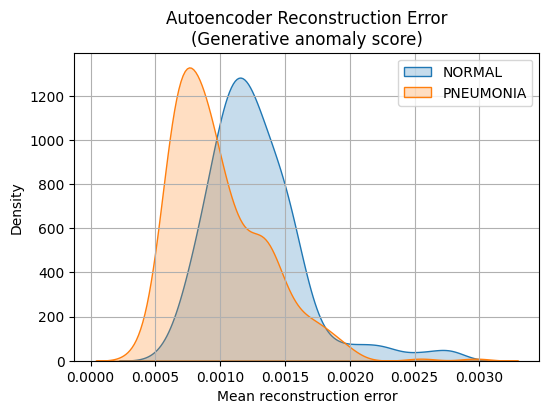

Mean error NORMAL   : 0.001265
Mean error PNEUMONIA: 0.000990


In [22]:
# Compare reconstruction error distributions for NORMAL vs PNEUMONIA

ae_model.eval()

errors_normal = []
errors_pneu   = []

with torch.no_grad():
    for idx in range(len(test_dataset_ae)):
        img, label = test_dataset_ae[idx]  # 1x224x224
        orig, recon, _ = generate_attention_map(ae_model, img, DEVICE)
        # Mean squared reconstruction error as scalar
        mse = np.mean((orig - recon) ** 2)
        if label == test_dataset_ae.class_to_idx["NORMAL"]:
            errors_normal.append(mse)
        else:
            errors_pneu.append(mse)

errors_normal = np.array(errors_normal)
errors_pneu   = np.array(errors_pneu)

plt.figure(figsize=(6,4))
sns.kdeplot(errors_normal, label="NORMAL", shade=True)
sns.kdeplot(errors_pneu,   label="PNEUMONIA", shade=True)
plt.xlabel("Mean reconstruction error")
plt.ylabel("Density")
plt.title("Autoencoder Reconstruction Error\n(Generative anomaly score)")
plt.legend()
plt.grid(True)
plt.savefig('AE_reconstruction_error_distributions.png', dpi=300)
plt.show()

print(f"Mean error NORMAL   : {errors_normal.mean():.6f}")
print(f"Mean error PNEUMONIA: {errors_pneu.mean():.6f}")